In [ ]:
import os
import zipfile
import cv2
import numpy as np


In [ ]:
zip_path = "/content/drive/MyDrive/ECG_images_classfication.zip"
extract_path = "/mnt/data/ecg_raw"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extracted to:", extract_path)


Extracted to: /mnt/data/ecg_raw


In [ ]:
def remove_header_footer_only(img_path):
    img = cv2.imread(img_path)

    if img is None:
        return None

    h, w, _ = img.shape

    # ==========================
    # REMOVE ONLY TOP & BOTTOM
    # ==========================
    top_cut = int(0.17 * h)      # removes ECG REPORT section
    bottom_cut = int(0.94 * h)   # removes footer text

    trimmed = img[top_cut:bottom_cut, :]  # keep full width

    return trimmed


In [ ]:
input_dir = "/mnt/data/ecg_raw"
output_dir = "/mnt/data/ecg_trimmed"

os.makedirs(output_dir, exist_ok=True)

for cls in os.listdir(input_dir):
    cls_input = os.path.join(input_dir, cls)
    cls_output = os.path.join(output_dir, cls)

    if not os.path.isdir(cls_input):
        continue

    os.makedirs(cls_output, exist_ok=True)

    for img_name in os.listdir(cls_input):
        img_path = os.path.join(cls_input, img_name)

        trimmed_img = remove_header_footer_only(img_path)

        if trimmed_img is None:
            continue

        cv2.imwrite(
            os.path.join(cls_output, img_name),
            trimmed_img
        )

    print(f"Processed: {cls}")


Processed: ECG Images of Patient that have abnormal heart beats (548)
Processed: Normal Person ECG Images (859)
Processed: ECG Images of Patient that have History of MI (203)
Processed: ECG Images of Myocardial Infarction Patients (77)
Processed: ECG Images of COVID-19 Patients (250)


Text(0.5, 1.0, 'Header & Footer Removed – ECG Box Preserved')

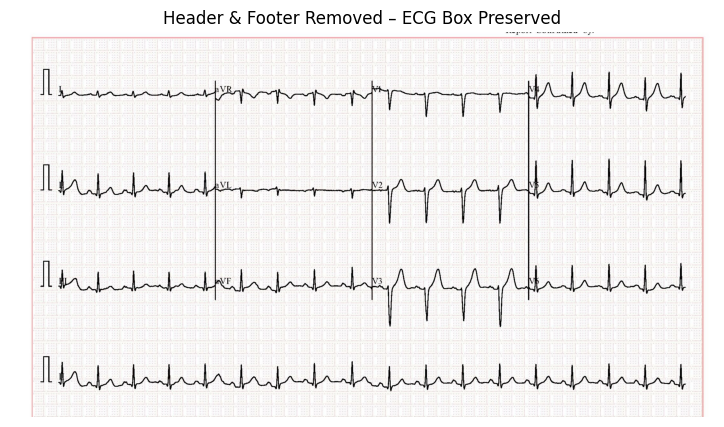

In [ ]:
import matplotlib.pyplot as plt

sample_class = os.listdir(output_dir)[0]
sample_img = os.listdir(os.path.join(output_dir, sample_class))[0]

img = cv2.imread(os.path.join(output_dir, sample_class, sample_img))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10,5))
plt.imshow(img)
plt.axis("off")
plt.title("Header & Footer Removed – ECG Box Preserved")


In [ ]:
import os

processed_path = "/mnt/data/ecg_trimmed"   # 🔴 change ONLY if your folder name is different

total = 0
for root, dirs, files in os.walk(processed_path):
    print(root, "->", len(files), "files")
    total += len(files)

print("Total images:", total)


/mnt/data/ecg_trimmed -> 0 files
/mnt/data/ecg_trimmed/ECG Images of Patient that have abnormal heart beats (548) -> 546 files
/mnt/data/ecg_trimmed/Normal Person ECG Images (859) -> 859 files
/mnt/data/ecg_trimmed/ECG Images of Patient that have History of MI (203) -> 203 files
/mnt/data/ecg_trimmed/ECG Images of Myocardial Infarction Patients (77) -> 74 files
/mnt/data/ecg_trimmed/ECG Images of COVID-19 Patients (250) -> 250 files
Total images: 1932


In [ ]:
import zipfile
import os

zip_path = "/content/ecg_trimmed_dataset.zip"

with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for root, dirs, files in os.walk(processed_path):
        for file in files:
            file_path = os.path.join(root, file)
            arcname = os.path.relpath(file_path, processed_path)
            zipf.write(file_path, arcname)

print("ZIP created at:", zip_path)


ZIP created at: /content/ecg_trimmed_dataset.zip
